# **XAI Project — K-Nearest Neighbors (KNN) Model**
### **Paper: A Comparative Analysis of LIME and SHAP Interpreters with Explainable ML-Based Diabetes Predictions**
---

# **Step 1 — Load Libraries & Preprocess Data**
---

In [ ]:
%matplotlib inline
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import PartialDependenceDisplay
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import shap
import lime
import lime.lime_tabular

print('All libraries loaded successfully ')

All libraries loaded successfully 


In [ ]:
import os
# Dataset loaded from local file (kagglehub replaced for offline execution)
file_path = '/home/claude/diabetic_data.csv'
df = pd.read_csv(file_path)

print('Dataset loaded from local file')
print('Original dataset shape:', df.shape)
df.head()


Dataset loaded from local file
Original dataset shape: (10000, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,1,1,Caucasian,Male,[50-60),?,5,11,9,8,...,No,Steady,Down,Steady,No,No,No,Ch,No,<30
1,2,2,Hispanic,Female,[30-40),?,3,13,4,9,...,No,Up,Steady,Up,No,No,No,No,No,<30
2,3,3,Caucasian,Female,[30-40),?,3,3,9,14,...,No,Up,Down,Steady,No,No,No,Ch,No,NO
3,4,4,Caucasian,Female,[60-70),?,6,1,12,8,...,No,No,Steady,No,No,No,No,Ch,No,>30
4,5,5,Caucasian,Male,[20-30),?,1,11,4,7,...,No,Steady,Down,No,No,No,No,Ch,No,NO


In [ ]:
df = df[df['race'] != '?']
df = df[df['gender'] != 'Unknown/Invalid']

def map_discharge(x):
    if x == 1:             return 'Home'
    elif x in [3, 6]:     return 'Care'
    elif x == 2:           return 'Transfer'
    elif x in [11,19,20,21]: return 'Death'
    elif x in [13, 14]:   return 'Hospice'
    elif x == 18:          return 'Unknown'
    else:                  return 'Other'

df['discharge_group'] = df['discharge_disposition_id'].apply(map_discharge)
df = df[df['discharge_group'] != 'Unknown']

df_c = df.drop(columns=[
    'discharge_disposition_id', 'metformin-pioglitazone',
    'glyburide-metformin', 'glimepiride-pioglitazone',
    'encounter_id', 'patient_nbr', 'weight', 'max_glu_serum',
    'A1Cresult', 'payer_code', 'medical_specialty',
    'glipizide-metformin', 'metformin-rosiglitazone',
    'examide', 'citoglipton', 'acetohexamide', 'troglitazone',
    'tolbutamide', 'tolazamide', 'chlorpropamide', 'miglitol',
    'acarbose', 'nateglinide', 'repaglinide'
])

def map_icd9(code):
    try:
        c = str(code).strip()
        if c.startswith('V'): return 'Supplementary'
        if c.startswith('E'): return 'External_Causes'
        n = float(c)
        if n < 140:  return 'Infectious'
        if n < 240:  return 'Neoplasms'
        if n < 280:  return 'Endocrine_Diabetes'
        if n < 290:  return 'Blood'
        if n < 320:  return 'Mental'
        if n < 360:  return 'Nervous_System'
        if n < 390:  return 'Sensory'
        if n < 460:  return 'Circulatory'
        if n < 520:  return 'Respiratory'
        if n < 580:  return 'Digestive'
        if n < 630:  return 'Genitourinary'
        if n < 680:  return 'Pregnancy'
        if n < 710:  return 'Skin'
        if n < 740:  return 'Musculoskeletal'
        if n < 760:  return 'Congenital'
        if n < 780:  return 'Perinatal'
        if n < 800:  return 'Symptoms'
        return 'Injury'
    except:
        return 'Other'

df_c['diag_1'] = df_c['diag_1'].apply(map_icd9)
df_c['diag_2'] = df_c['diag_2'].apply(map_icd9)
df_c['diag_3'] = df_c['diag_3'].apply(map_icd9)

df_c.drop_duplicates(inplace=True)

readmit_map = {'NO': 0, '>30': 1, '<30': 2}
df_c['readmitted'] = df_c['readmitted'].map(readmit_map)

print('Preprocessing done ')
print('Shape after cleaning:', df_c.shape)

Preprocessing done 
Shape after cleaning: (10000, 27)


In [ ]:
cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient',
               'num_medications', 'time_in_hospital']
for col in cols_to_fix:
    df_c[col] = np.log1p(df_c[col])

cat_cols = df_c.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_c[col] = le.fit_transform(df_c[col].astype(str))

print('Encoding done. Categorical columns encoded:', cat_cols)
print('Final shape:', df_c.shape)

Encoding done. Categorical columns encoded: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'discharge_group']
Final shape: (10000, 27)


# **Step 2 — Feature Selection & Train/Test Split**
---

In [ ]:
X = df_c.drop(columns=['readmitted'])
y = df_c['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Class distribution (train):\n{y_train.value_counts()}')

Train size : (8000, 26)
Test size  : (2000, 26)
Class distribution (train):
readmitted
0    4334
1    2791
2     875
Name: count, dtype: int64


# **Step 3 — KNN Model Building & Hyperparameter Tuning**
---

In [ ]:
param_grid = {
    'model__n_neighbors': [5, 9, 15],
    'model__weights'    : ['uniform', 'distance'],
    'model__metric'     : ['euclidean']
}

knn_pipeline = ImbPipeline(steps=[
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\nBest Parameters:', grid_search.best_params_)
print(f'Best CV F1-Score: {grid_search.best_score_*100:.2f}%')

Fitting 5 folds for each of 6 candidates, totalling 30 fits



Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'uniform'}
Best CV F1-Score: 36.81%


In [ ]:
knn_best = grid_search.best_estimator_

y_pred      = knn_best.predict(X_test)
y_pred_prob = knn_best.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred) * 100
f1  = f1_score(y_test, y_pred, average='weighted') * 100
prec = precision_score(y_test, y_pred, average='weighted') * 100
rec  = recall_score(y_test, y_pred, average='weighted') * 100
model_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted') * 100

print('='*50)
print('   KNN MODEL — TEST SET PERFORMANCE')
print('='*50)
print(f'  Accuracy  : {acc:.2f}%')
print(f'  Precision : {prec:.2f}%')
print(f'  Recall    : {rec:.2f}%')
print(f'  F1-Score  : {f1:.2f}%')
print(f'  AUC-ROC   : {model_auc:.2f}%')
print('='*50)
print()
print(classification_report(y_test, y_pred,
      target_names=['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']))

   KNN MODEL — TEST SET PERFORMANCE
  Accuracy  : 35.95%
  Precision : 43.22%
  Recall    : 35.95%
  F1-Score  : 38.52%
  AUC-ROC   : 50.33%

                precision    recall  f1-score   support

No Readmit (0)       0.55      0.40      0.46      1083
  >30 Days (1)       0.35      0.33      0.34       698
  <30 Days (2)       0.10      0.26      0.15       219

      accuracy                           0.36      2000
     macro avg       0.33      0.33      0.32      2000
  weighted avg       0.43      0.36      0.39      2000



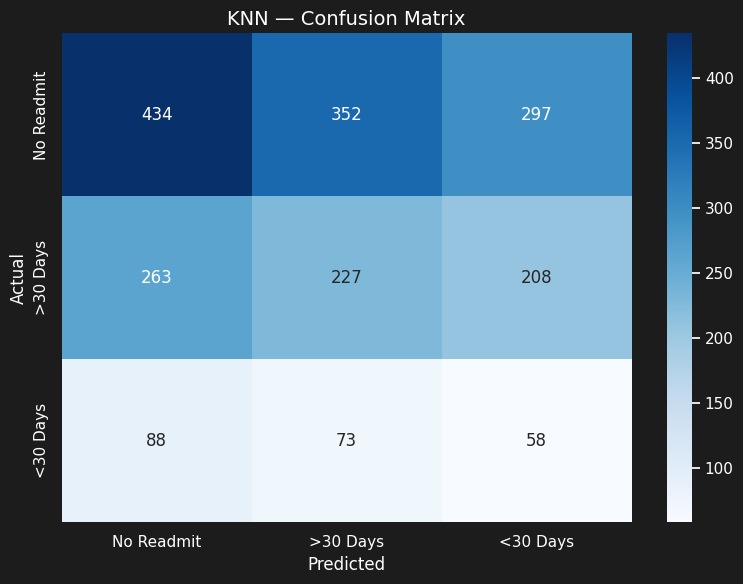

Saved → knn_confusion_matrix.png


In [ ]:
sns.set_theme(style='darkgrid', rc={
    'axes.facecolor': '#242424', 'figure.facecolor': '#1c1c1c',
    'grid.color': '#444444', 'text.color': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white'
})

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Readmit', '>30 Days', '<30 Days'],
            yticklabels=['No Readmit', '>30 Days', '<30 Days'])
plt.title('KNN — Confusion Matrix', color='white', fontsize=14)
plt.ylabel('Actual', color='white')
plt.xlabel('Predicted', color='white')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_confusion_matrix.png')

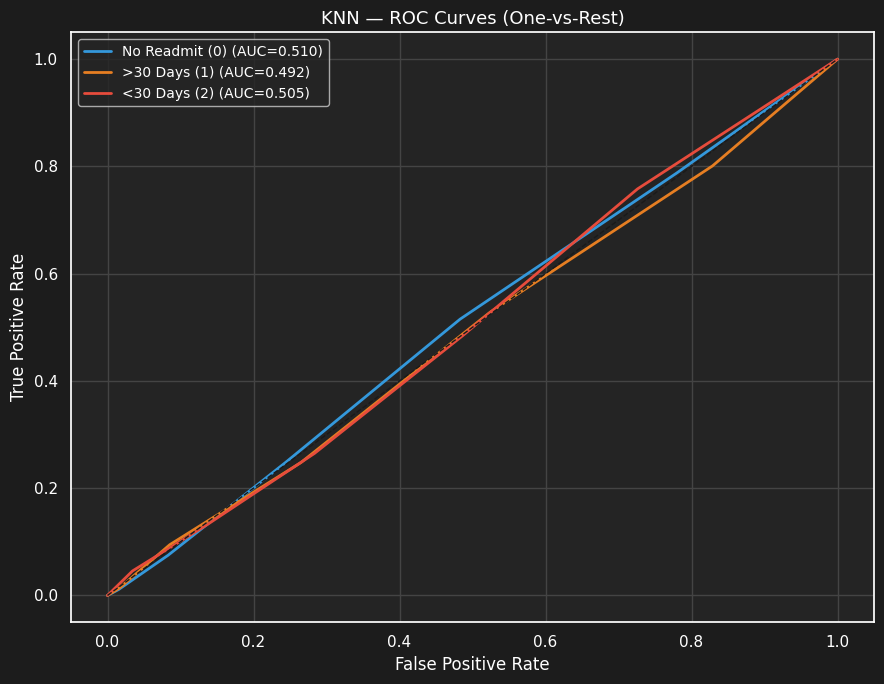

Saved → knn_roc_curves.png


In [ ]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']
colors_roc  = ['#3498db', '#e67e22', '#e74c3c']

plt.figure(figsize=(9, 7))
for i, (name, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_i   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc_i:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate', color='white')
plt.ylabel('True Positive Rate', color='white')
plt.title('KNN — ROC Curves (One-vs-Rest)', color='white', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('knn_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_roc_curves.png')

Cross-Validation F1 (10-fold): 37.14% ± 1.94%


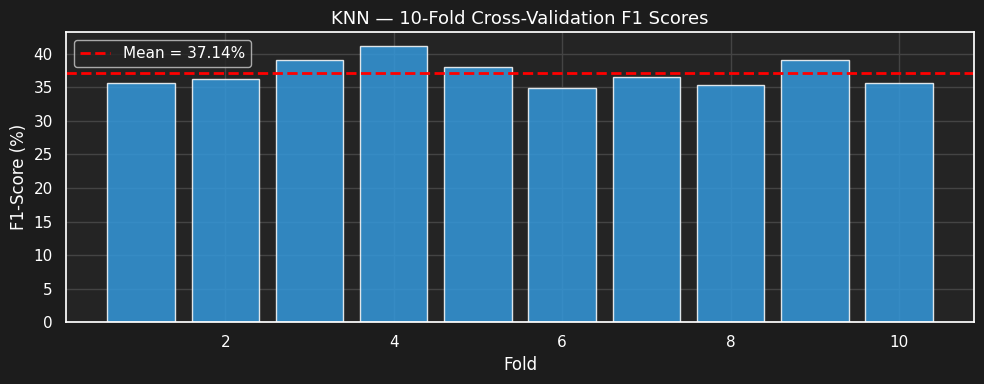

In [ ]:
cv_scores = cross_val_score(knn_best, X_train, y_train,
                            cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
                            scoring='f1_weighted', n_jobs=-1)

print(f'Cross-Validation F1 (10-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), cv_scores * 100, color='#3498db', edgecolor='white', alpha=0.85)
plt.axhline(cv_scores.mean()*100, color='red', linestyle='--', lw=2,
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold', color='white')
plt.ylabel('F1-Score (%)', color='white')
plt.title('KNN — 10-Fold Cross-Validation F1 Scores', color='white', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('knn_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# **Step 4 — Explainability Technique 1: SHAP**
### Global & Local explanations using KernelSHAP
---

In [ ]:
scaler = knn_best.named_steps['scaler']
knn_model = knn_best.named_steps['model']

X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
X_train_scaled = scaler.transform(X_train_smote)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

background = shap.sample(X_train_scaled_df, 30, random_state=42)

explainer_shap = shap.KernelExplainer(
    knn_model.predict_proba,
    background
)

print('Computing SHAP values on 50 test samples (KernelSHAP)...')
shap_values_raw = explainer_shap.shap_values(X_test_scaled_df.iloc[:50])
# Handle 3D array output from SHAP 0.51+ (samples, features, classes) -> list per class
if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = [shap_values_raw[:, :, c] for c in range(shap_values_raw.shape[2])]
else:
    shap_values = shap_values_raw
shap_values = shap_values
print('SHAP computation done ')

Computing SHAP values on 50 test samples (KernelSHAP)...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP computation done 


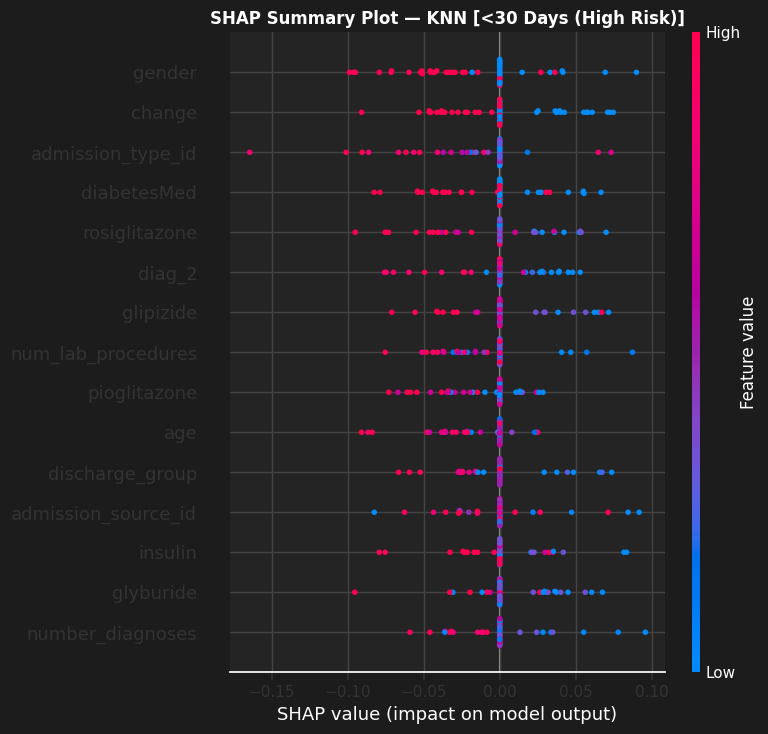

Saved → knn_shap_summary_class2.png


In [ ]:
TARGET_CLASS      = 2
TARGET_CLASS_NAME = '<30 Days (High Risk)'

plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_values[TARGET_CLASS],
    X_test_scaled_df.iloc[:50],
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title(f'SHAP Summary Plot — KNN [{TARGET_CLASS_NAME}]',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_shap_summary_class2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_shap_summary_class2.png')

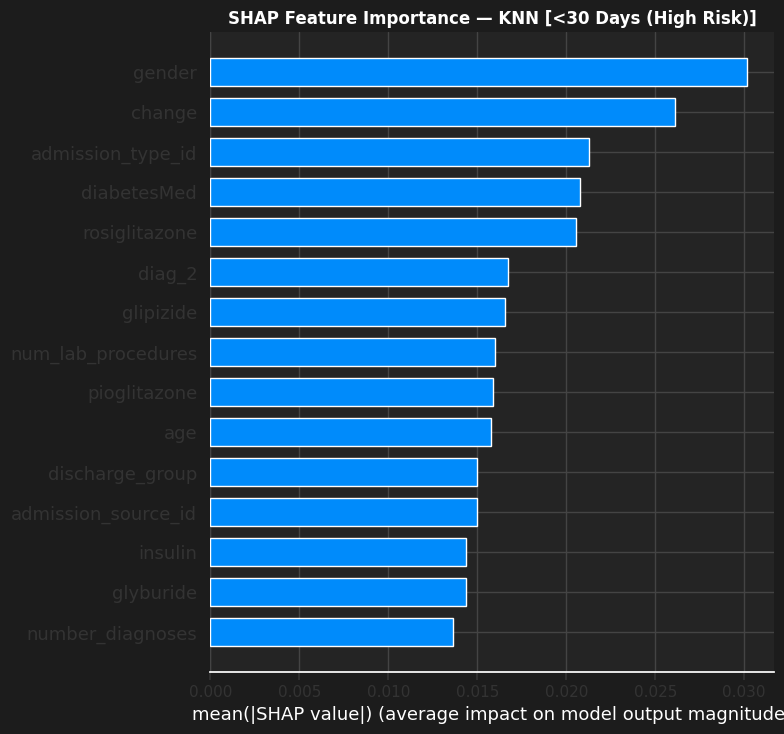

Saved → knn_shap_bar_class2.png


In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[TARGET_CLASS],
    X_test_scaled_df.iloc[:50],
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title(f'SHAP Feature Importance — KNN [{TARGET_CLASS_NAME}]',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_shap_bar_class2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_shap_bar_class2.png')

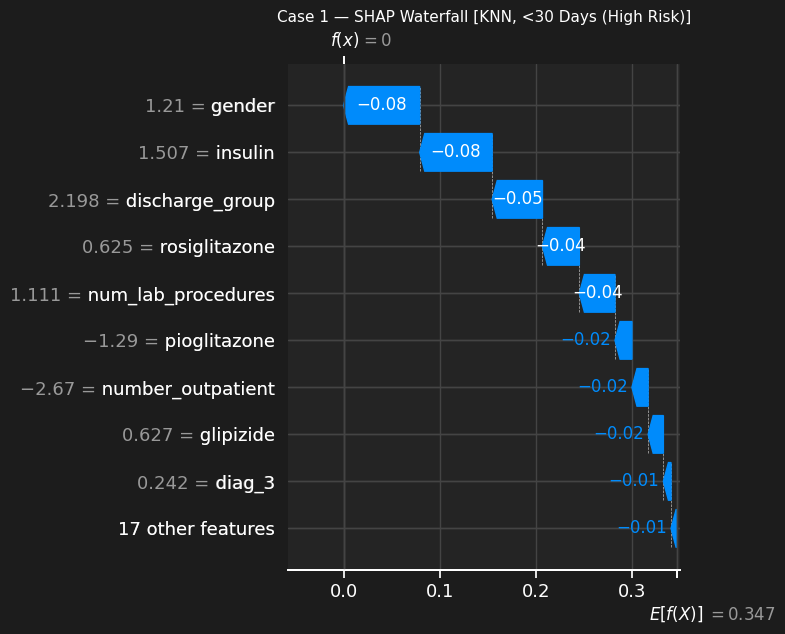

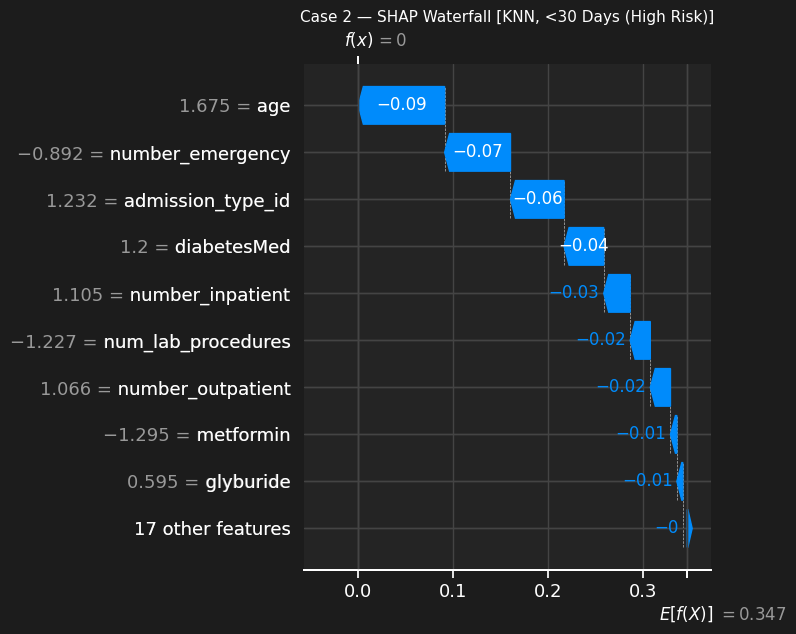

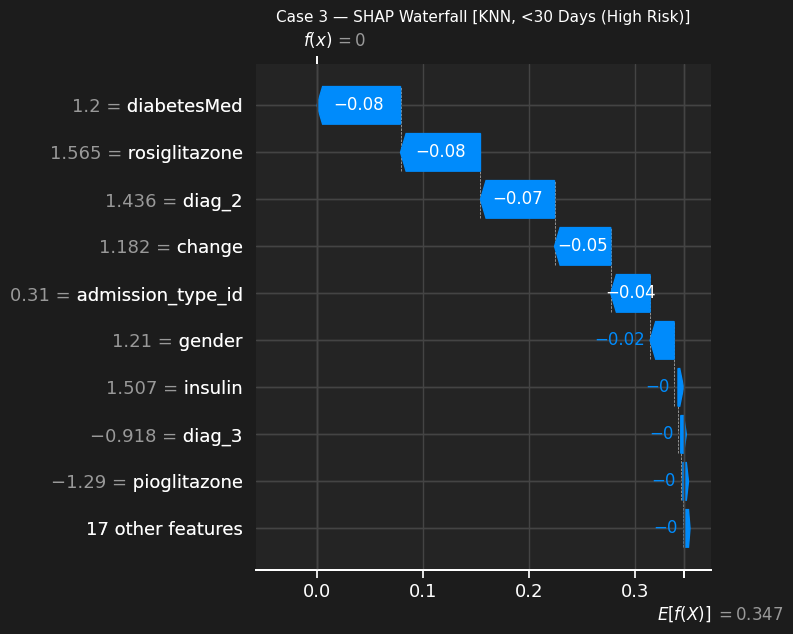

Waterfall plots saved 


In [ ]:
for case_idx, label in [(0, 'Case 1'), (5, 'Case 2'), (10, 'Case 3')]:
    shap_exp = shap.Explanation(
        values      = shap_values[TARGET_CLASS][case_idx],
        base_values = explainer_shap.expected_value[TARGET_CLASS] if hasattr(explainer_shap.expected_value, '__len__') else explainer_shap.expected_value,
        data        = X_test_scaled_df.iloc[case_idx].values,
        feature_names = X.columns.tolist()
    )
    plt.figure(figsize=(12, 4))
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.title(f'{label} — SHAP Waterfall [KNN, {TARGET_CLASS_NAME}]', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'knn_shap_waterfall_{label.replace(" ","_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Waterfall plots saved ')

# **Step 5 — Explainability Technique 2: LIME**
### Local Instance Explanations
---

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_scaled,
    feature_names  = X.columns.tolist(),
    class_names    = ['No Readmit', '>30 Days', '<30 Days'],
    mode           = 'classification',
    random_state   = 42
)

print('LIME explainer created ')

LIME explainer created 


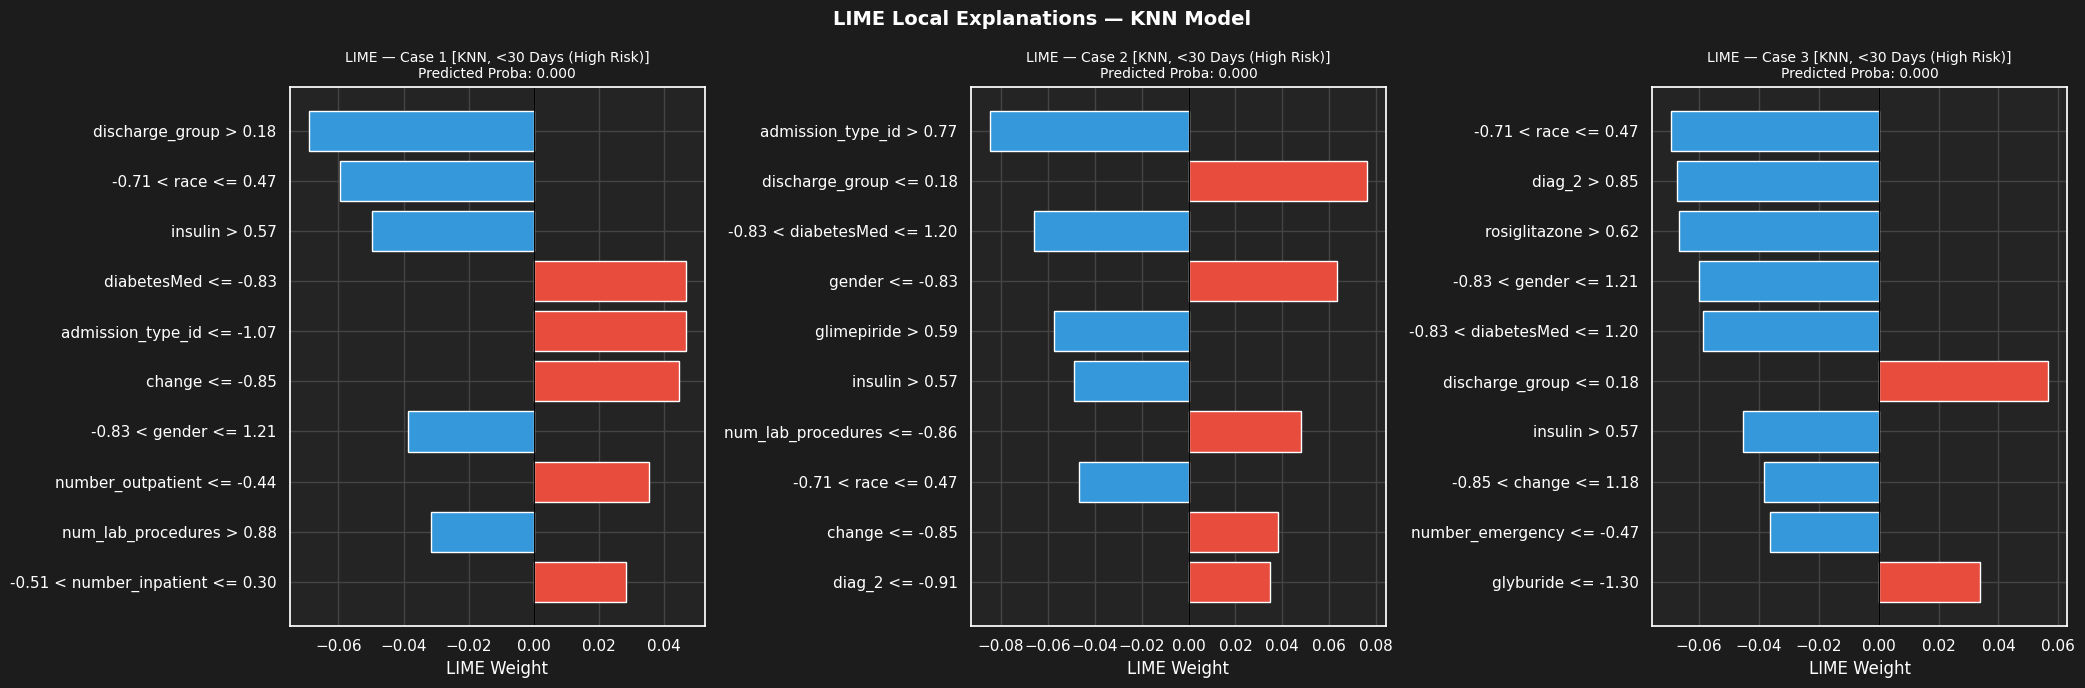

Saved → knn_lime_explanations.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for plot_i, (case_idx, ax) in enumerate(zip([0, 5, 10], axes)):
    exp = lime_explainer.explain_instance(
        data_row      = X_test_scaled_df.iloc[case_idx].values,
        predict_fn    = knn_model.predict_proba,
        num_features  = 10,
        labels        = (TARGET_CLASS,)
    )

    features_vals = exp.as_list(label=TARGET_CLASS)
    features_names = [fv[0] for fv in features_vals]
    weights        = [fv[1] for fv in features_vals]
    colors = ['#e74c3c' if w > 0 else '#3498db' for w in weights]

    ax.barh(features_names[::-1], weights[::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LIME — Case {plot_i+1} [KNN, {TARGET_CLASS_NAME}]\n'
                 f'Predicted Proba: {knn_model.predict_proba(X_test_scaled_df.iloc[[case_idx]].values)[0][TARGET_CLASS]:.3f}',
                 fontsize=10)
    ax.set_xlabel('LIME Weight')

plt.suptitle('LIME Local Explanations — KNN Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_lime_explanations.png')

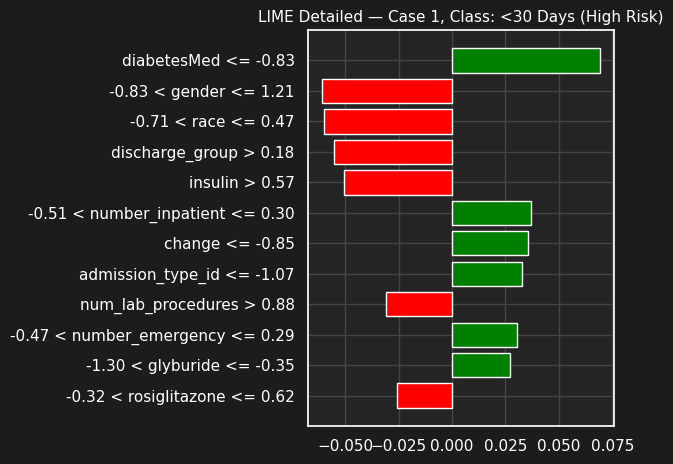

Saved → knn_lime_case1_detail.png


In [ ]:
exp_case1 = lime_explainer.explain_instance(
    data_row   = X_test_scaled_df.iloc[0].values,
    predict_fn = knn_model.predict_proba,
    num_features = 12,
    labels = (0, 1, 2)
)

fig = exp_case1.as_pyplot_figure(label=TARGET_CLASS)
plt.title(f'LIME Detailed — Case 1, Class: {TARGET_CLASS_NAME}', fontsize=11)
plt.tight_layout()
plt.savefig('knn_lime_case1_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_lime_case1_detail.png')

# **Step 6 — Explainability Technique 3: Partial Dependence Plots (PDP)**
### Shows marginal effect of each feature on predictions
---

In [ ]:
mean_abs_shap = np.abs(shap_values[TARGET_CLASS]).mean(axis=0)
top5_indices  = np.argsort(mean_abs_shap)[::-1][:5]
top5_features = [X.columns[i] for i in top5_indices]

print('Top 5 features by SHAP importance:', top5_features)

Top 5 features by SHAP importance: ['gender', 'change', 'admission_type_id', 'diabetesMed', 'rosiglitazone']


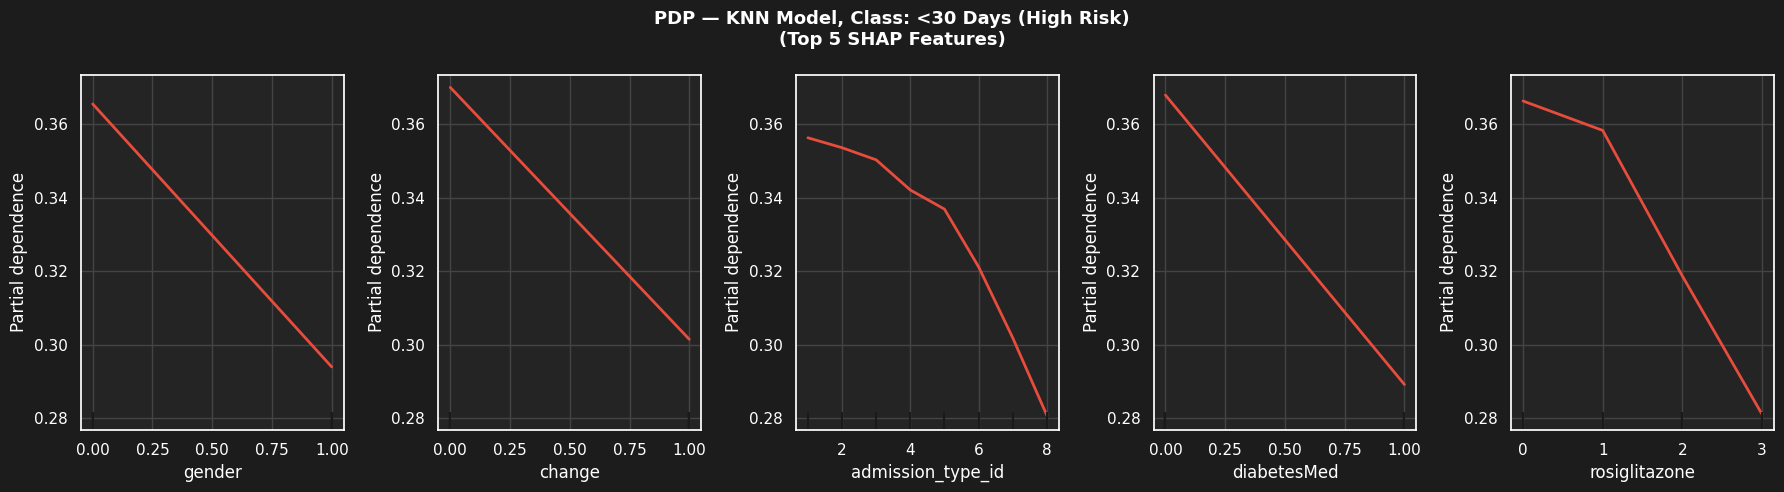

Saved → knn_pdp_top5.png


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class WrappedKNN(ClassifierMixin, BaseEstimator):  # ClassifierMixin first for sklearn 1.8+ is_classifier()
    def __init__(self, scaler, model):
        self.scaler = scaler
        self.model  = model
        self.classes_ = model.classes_

    def fit(self, X, y):
        self.is_fitted_ = True
        return self
    def __sklearn_is_fitted__(self):
        return True

    def predict(self, X):
        return self.model.predict(self.scaler.transform(X))

    def predict_proba(self, X):
        return self.model.predict_proba(self.scaler.transform(X))

wrapped_knn = WrappedKNN(scaler, knn_model)
wrapped_knn.fit(X_train, y_train)  # mark as fitted

fig, axes = plt.subplots(1, len(top5_features), figsize=(18, 5))
PartialDependenceDisplay.from_estimator(
    wrapped_knn,
    X_test,
    features = top5_indices[:5].tolist(),
    feature_names = X.columns.tolist(),
    target  = TARGET_CLASS,
    kind    = 'average',
    ax      = axes,
    line_kw = {'color': '#e74c3c', 'linewidth': 2}
)

fig.suptitle(f'PDP — KNN Model, Class: {TARGET_CLASS_NAME}\n(Top 5 SHAP Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_pdp_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_pdp_top5.png')

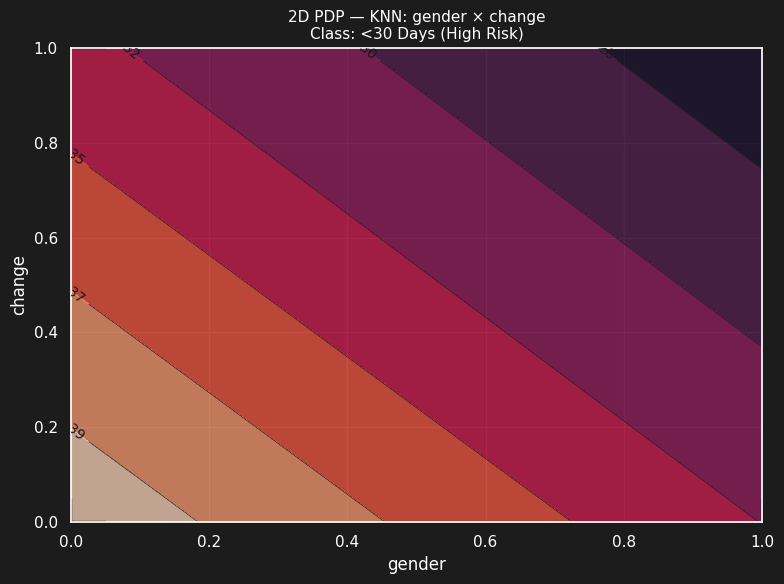

Saved → knn_pdp_2d.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    wrapped_knn,
    X_test,
    features = [(top5_indices[0], top5_indices[1])],
    feature_names = X.columns.tolist(),
    target  = TARGET_CLASS,
    kind    = 'average',
    ax      = [ax]
)
ax.set_title(f'2D PDP — KNN: {top5_features[0]} × {top5_features[1]}\nClass: {TARGET_CLASS_NAME}',
             fontsize=11)
plt.tight_layout()
plt.savefig('knn_pdp_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_pdp_2d.png')

# **Step 7 — Explainability Technique 4: Permutation Feature Importance**
### Model-agnostic feature importance based on performance drop
---

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    wrapped_knn,
    X_test,
    y_test,
    n_repeats   = 10,
    random_state= 42,
    scoring     = 'f1_weighted',
    n_jobs      = -1
)

perm_df = pd.DataFrame({
    'Feature'          : X.columns,
    'Importance_Mean'  : perm_result.importances_mean,
    'Importance_Std'   : perm_result.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

print('Top 15 Features by Permutation Importance:')
print(perm_df.head(15).to_string(index=False))

Top 15 Features by Permutation Importance:
            Feature  Importance_Mean  Importance_Std
   number_diagnoses         0.009427        0.006735
            insulin         0.008981        0.005332
             diag_1         0.008436        0.006767
admission_source_id         0.006944        0.011349
          glipizide         0.006199        0.007090
             diag_3         0.006139        0.007513
      rosiglitazone         0.006106        0.004744
          metformin         0.005348        0.006426
     num_procedures         0.004732        0.005243
   number_emergency         0.004675        0.006341
   time_in_hospital         0.004211        0.007240
  admission_type_id         0.003424        0.007430
       pioglitazone         0.003057        0.005585
             diag_2         0.001757        0.009467
   number_inpatient         0.001418        0.008167


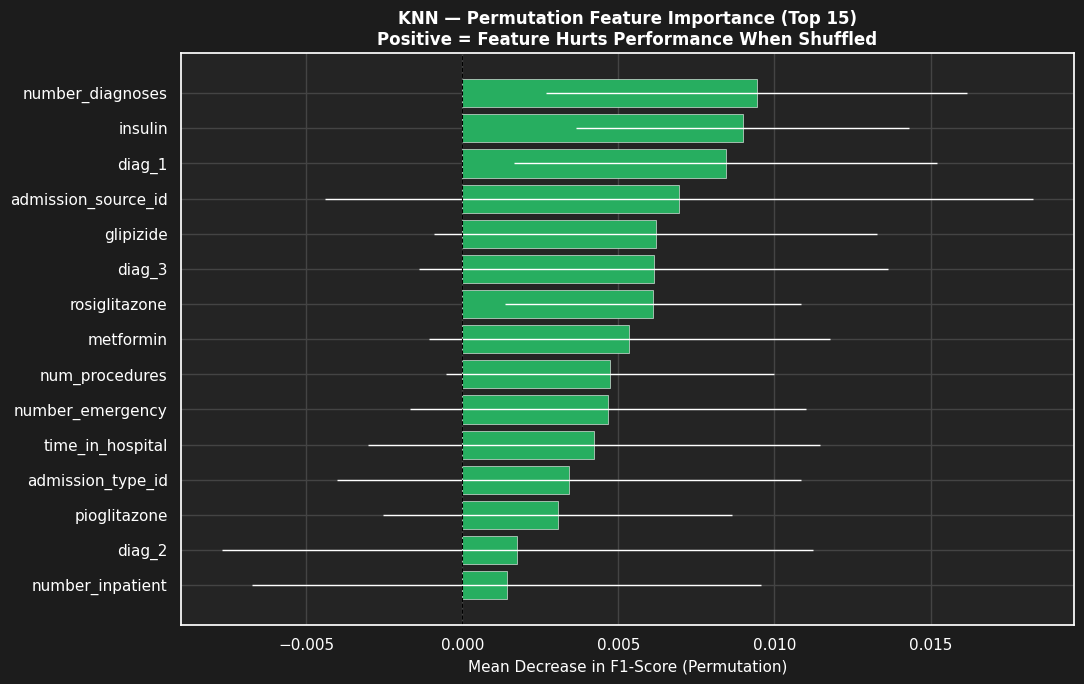

Saved → knn_permutation_importance.png


In [ ]:
top15_perm = perm_df.head(15)

fig, ax = plt.subplots(figsize=(11, 7))
colors_perm = ['#27ae60' if v > 0 else '#e74c3c' for v in top15_perm['Importance_Mean']]
bars = ax.barh(
    top15_perm['Feature'][::-1],
    top15_perm['Importance_Mean'][::-1],
    xerr  = top15_perm['Importance_Std'][::-1],
    color = colors_perm[::-1],
    edgecolor='white', linewidth=0.4,
    error_kw={'ecolor':'white', 'linewidth':1}
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean Decrease in F1-Score (Permutation)', fontsize=11)
ax.set_title('KNN — Permutation Feature Importance (Top 15)\n'
             'Positive = Feature Hurts Performance When Shuffled',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_permutation_importance.png')

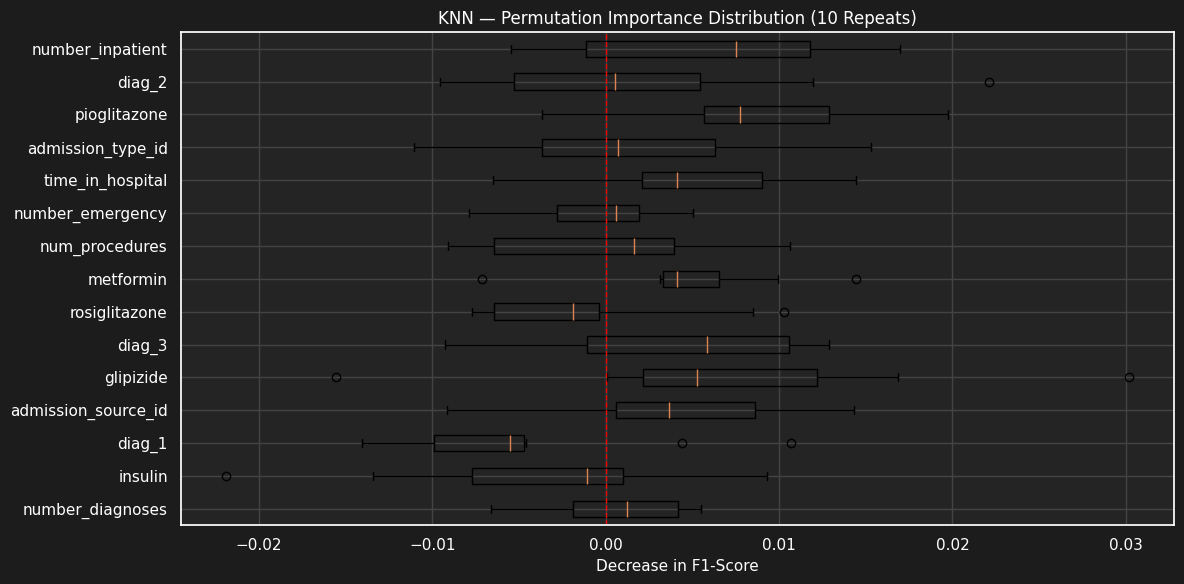

Saved → knn_permutation_boxplot.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(
    perm_result.importances[perm_df.index[:15]].T,
    vert=False,
    labels=perm_df['Feature'][:15].tolist()
)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Decrease in F1-Score', fontsize=11)
ax.set_title('KNN — Permutation Importance Distribution (10 Repeats)', fontsize=12)
plt.tight_layout()
plt.savefig('knn_permutation_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_permutation_boxplot.png')

# **Step 8 — Summary: Comparing All 4 Explainability Techniques**
---

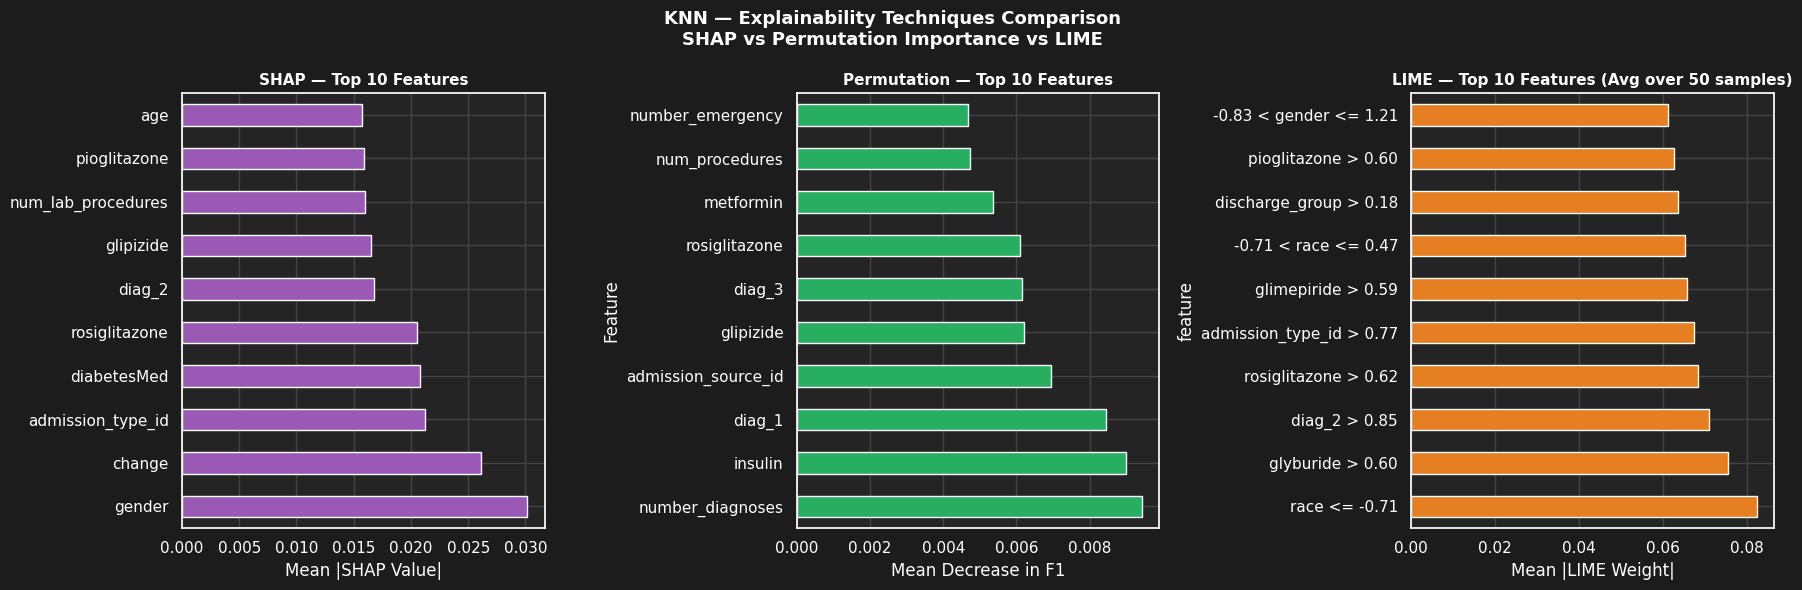

Saved → knn_explainability_comparison.png


In [ ]:
shap_top10  = pd.Series(mean_abs_shap, index=X.columns).nlargest(10)
perm_top10  = perm_df.set_index('Feature')['Importance_Mean'].nlargest(10)

lime_weights_all = []
for i in range(20):
    exp_i = lime_explainer.explain_instance(
        X_test_scaled_df.iloc[i].values,
        knn_model.predict_proba,
        num_features=len(X.columns),
        labels=(TARGET_CLASS,)
    )
    for feat, weight in exp_i.as_list(label=TARGET_CLASS):
        clean_feat = feat.split(' ')[0] if ' ' in feat else feat
        lime_weights_all.append({'feature': feat, 'weight': abs(weight)})

lime_df = pd.DataFrame(lime_weights_all)
lime_top10 = lime_df.groupby('feature')['weight'].mean().nlargest(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

shap_top10.plot(kind='barh', ax=axes[0], color='#9b59b6')
axes[0].set_title('SHAP — Top 10 Features', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Mean |SHAP Value|')

perm_top10.plot(kind='barh', ax=axes[1], color='#27ae60')
axes[1].set_title('Permutation — Top 10 Features', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Decrease in F1')

lime_top10.plot(kind='barh', ax=axes[2], color='#e67e22')
axes[2].set_title('LIME — Top 10 Features (Avg over 50 samples)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Mean |LIME Weight|')

plt.suptitle('KNN — Explainability Techniques Comparison\nSHAP vs Permutation Importance vs LIME',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_explainability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → knn_explainability_comparison.png')

In [ ]:
print('   KNN MODEL — FINAL SUMMARY')

print(f'  Best K             : {knn_best.named_steps["model"].n_neighbors}')
print(f'  Best Weights       : {knn_best.named_steps["model"].weights}')
print(f'  Best Metric        : {knn_best.named_steps["model"].metric}')
print()
print(f'  Accuracy           : {acc:.2f}%')
print(f'  Precision          : {prec:.2f}%')
print(f'  Recall             : {rec:.2f}%')
print(f'  F1-Score           : {f1:.2f}%')
print(f'  AUC-ROC            : {model_auc:.2f}%')
print(f'  CV F1 (10-fold)    : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print()
print('  Explainability Techniques Applied:')
print('   1. SHAP (KernelSHAP) — Summary, Bar, Waterfall plots')
print('   2. LIME — Local instance explanations')
print('   3. PDP  — 1D and 2D Partial Dependence Plots')
print('   4. Permutation Feature Importance — Boxplot & Bar')


   KNN MODEL — FINAL SUMMARY
  Best K             : 5
  Best Weights       : uniform
  Best Metric        : euclidean

  Accuracy           : 35.95%
  Precision          : 43.22%
  Recall             : 35.95%
  F1-Score           : 38.52%
  AUC-ROC            : 50.33%
  CV F1 (10-fold)    : 37.14% ± 1.94%

  Explainability Techniques Applied:
   1. SHAP (KernelSHAP) — Summary, Bar, Waterfall plots
   2. LIME — Local instance explanations
   3. PDP  — 1D and 2D Partial Dependence Plots
   4. Permutation Feature Importance — Boxplot & Bar
